# Display fix: making the third channel identifiable

**Why this notebook exists.** In
`final-tv-test-under-real-demo-data-roi-shape-coupling.ipynb`, the `default`
prior variant fails on *two* channels, but for two different reasons:

- **TV** fails because it operates at 8% of its ceiling -- deep in the
  near-linear regime where only the ratio `beta/ec` enters the likelihood, so
  `ec_m` is structurally unidentifiable. This is the finding the whole study
  is about.
- **Display** fails for an unrelated and uninteresting reason: it is simply
  *too small to see*. At `target_audience_pop_frac=0.10` sourced from the real
  `Channel0`, it contributes ~3.7% of total media effect and its delivery
  barely moves week to week (p95/p5 of 3.3x). Its shape signal comes to ~0.2x
  the noise-detection threshold, so nothing about it is identified -- `ec_m`
  drifts, `eta_m` inflates ~3000x above a true 0.0008, and `roi_m` blows up to
  ~25x against a true 3.9 with an interval so wide it flips between covering
  and missing the truth depending on the seed.

That second failure is noise in the argument. It invites the objection "your
method fails on 2 of 3 channels" when the honest claim is "it fails on
under-reached channels, and Display is not one -- it is just invisible."

**The fix, and why it is safe.** `ec_m` is derived in
`simulate_adstock_hill_params()` as roughly

```
ec_m  ~  saturation_frequency / (current_reach_frac * frequency)
```

-- **audience size cancels out**. So raising
`target_audience_pop_frac['Display']` scales Display's impressions, spend and
KPI contribution up while leaving its `ec_m` (and therefore its 42%-of-ceiling
position on the saturation curve) exactly where it was. Reach and frequency
would *not* be safe levers: both move `ec_m` and would slide Display along its
curve, destroying its role as the intermediate case between TV and Social.

Two changes, both `ec_m`-neutral:

1. `target_audience_pop_frac['Display']`: **0.10 -> 0.50** (contribution share
   3.7% -> ~16%).
2. Source Display from **`Channel2_impression`** instead of `Channel0`
   (delivery spread 3.3x -> 8.4x). `Channel2` is free now that Social uses
   `Channel1`.

**The prediction being tested:** Display's detectability rises from 0.19x to
~1.35x of the noise threshold, and it should recover under `default`. That is
*marginal* -- the detectability metric is an optimistic bound that ignores the
`mu_t` spline, geo effects and `eta_m` all competing to absorb the same
variation. If Display still fails, the escalation is audience 0.70 (1.89x) or a
higher `target_roi['Display']`, both also `ec_m`-neutral.

Nothing here modifies the existing notebooks or their saved fits; this run
writes to its own `fitted_models/display_fix/` directory.

In [1]:
import json
import os
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median

OUT_DIR = 'fitted_models/display_fix'
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Build the Display-fixed scenario

Identical to the parent notebook except for the two Display changes noted
above. Seeded with `SIM_SEED = 0` to match the parent run's saved fits, so any
difference in the comparison table is attributable to the Display change rather
than to a different simulator draw.

I0000 00:00:1785252333.235421 8912656 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3505481   0.29689494]


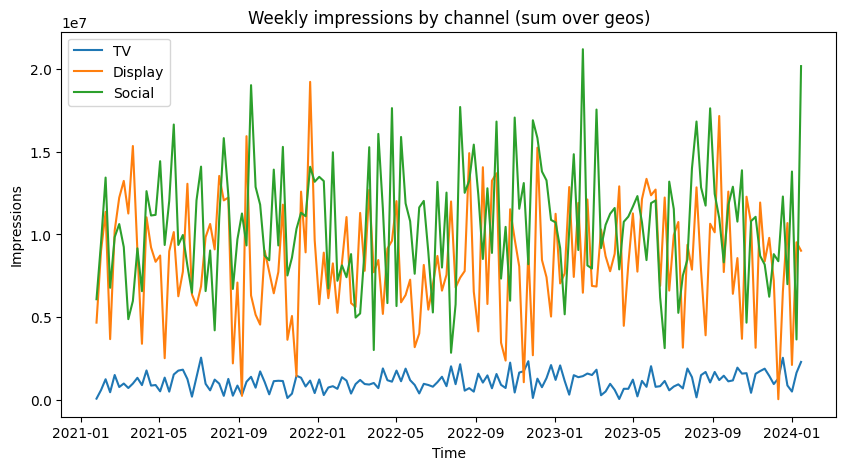

In [2]:
DISPLAY_FIX_CONFIG_OVERRIDES = {
    # Display audience 0.10 -> 0.50. ec_m-neutral (see header): ec_m depends on
    # saturation_frequency / (reach * frequency), in which audience cancels.
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.50, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
}
SIM_SEED = 0
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)
np.random.seed(SIM_SEED)
tf.random.set_seed(SIM_SEED)
config = SimulationConfig.from_dict(DISPLAY_FIX_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config,
    real_df,
    rf_source_map={'TV': 'Channel3'},
    # Display moves Channel0 -> Channel2 for delivery variation; Channel2 is
    # unused now that Social sources from Channel1.
    plain_source_map={'Display': 'Channel2', 'Social': 'Channel1'},
)
channels = list(config.channel_names)
sim.plot_media_time_series()
plt.show()

### 1a. Confirm the fix did what it was supposed to -- and nothing else

The whole justification rests on the audience lever being `ec_m`-neutral. If
Display's `ec_m` moved materially, it would no longer be the intermediate
(~42% of ceiling) case and the scenario's structure would have changed
underneath us. Assert it rather than eyeball it.

We also want the channels to stay mutually uncorrelated -- the parent notebook
went to some trouble to decorrelate TV and Social, and adding `Channel2`
must not reintroduce collinearity on a different pair.

In [3]:
true_ec_m = sim.ec_m.numpy()
ceiling_frac = ceiling_fraction_at_median(true_ec_m)
i_disp = channels.index('Display')

# Display's ec_m under the parent (audience 0.10, Channel0) scenario was 1.383,
# and 1.351 sourced from Channel2. The audience change must not move it.
assert 1.2 < true_ec_m[i_disp] < 1.5, (
    f'Display ec_m moved to {true_ec_m[i_disp]:.3f} -- the audience lever was'
    ' supposed to be ec_m-neutral; the scenario structure has changed.'
)
assert 0.38 < ceiling_frac[i_disp] < 0.46, (
    'Display is no longer the intermediate ~42%-of-ceiling case.'
)

mt = sim.media_transformed.numpy()
corr = np.median([np.corrcoef(mt[g].T) for g in range(mt.shape[0])], axis=0)
corr_df = pd.DataFrame(corr, index=channels, columns=channels).round(3)
max_off_diag = np.abs(corr - np.eye(len(channels))).max()
assert max_off_diag < 0.3, (
    f'Channels are collinear (max |corr| = {max_off_diag:.2f}) -- check sources.'
)

print('true ec_m           :', np.round(true_ec_m, 3))
print('ceiling frac @ median:', np.round(ceiling_frac, 3))
print('true roi_m          :', np.round(np.asarray(ground_truth['roi_m']), 3))
print('\nwithin-geo correlation of transformed media (post adstock+Hill):')
print(corr_df)

true ec_m           : [11.069  1.351  0.297]
ceiling frac @ median: [0.083 0.425 0.771]
true roi_m          : [5.898 3.893 5.226]

within-geo correlation of transformed media (post adstock+Hill):
            TV  Display  Social
TV       1.000    0.044   0.066
Display  0.044    1.000   0.016
Social   0.066    0.016   1.000


### 1b. Did Display actually become visible?

The diagnostic that motivated this change, recomputed. `shape signal` asks: if
this channel's `ec_m` were wrong by a factor of two, and `beta` rescaled itself
to disguise that as well as it possibly could, how large is the leftover
mismatch in KPI units? That leftover is the only evidence the data has for
rejecting a wrong `ec_m`. `detectability` compares it to the standard error of
a systematic pattern given the KPI's residual noise.

Values below 1.0 mean the evidence is smaller than the noise floor -- the data
cannot distinguish the true `ec_m` from one twice as large, and whatever the
posterior reports is inherited from the prior.

**This is an optimistic bound**: it ignores that the `mu_t` spline, geo effects
and `eta_m` all compete to absorb the same variation, so true identifiability
is worse than the number shown.

In [4]:
def shape_diagnostics(sim, config, ec_multiple=2.0):
  """Per-channel delivery range, KPI contribution, and ec_m detectability."""
  channels = list(config.channel_names)
  ec = sim.ec_m.numpy()
  x = sim.transformed_ipc_gtm.numpy()
  contrib = sim.media_transformed.numpy() * sim.beta_gm.numpy()[:, None, :]
  noise_sd = float(sim.sigma.numpy()[0])
  n_obs = contrib.shape[0] * contrib.shape[1]
  se = noise_sd / np.sqrt(n_obs)
  hill = lambda v, e: v / (v + e)

  rows = []
  for i, ch in enumerate(channels):
    v = x[:, :, i].ravel()
    v = v[v > 0]
    p5, p95 = np.percentile(v, [5, 95])
    true_curve = hill(v, ec[i])
    wrong_curve = hill(v, ec[i] * ec_multiple)
    best_rescale = (true_curve @ wrong_curve) / (wrong_curve @ wrong_curve)
    resid = true_curve - best_rescale * wrong_curve
    frac = np.sqrt((resid**2).mean()) / np.sqrt((true_curve**2).mean())
    mean_contrib = contrib[:, :, i].mean()
    rows.append({
        'channel': ch,
        'ceiling_frac': round(float(1.0 / (1.0 + ec[i])), 3),
        'delivery_range_p95_p5': round(float(p95 / p5), 1),
        'mean_contrib': round(float(mean_contrib), 3),
        'contrib_share_pct': round(
            float(mean_contrib / contrib.mean(axis=(0, 1)).sum() * 100), 1),
        'shape_signal_kpi': round(float(frac * mean_contrib), 4),
        'detectability': round(float(frac * mean_contrib / se), 2),
    })
  return pd.DataFrame(rows)


diag = shape_diagnostics(sim, config)
print('Parent scenario for reference: Display contrib share 3.7%, '
      'range 3.3x, detectability 0.19x\n')
diag

Parent scenario for reference: Display contrib share 3.7%, range 3.3x, detectability 0.19x



,channel,ceiling_frac,delivery_range_p95_p5,mean_contrib,contrib_share_pct,shape_signal_kpi,detectability
0,TV,0.083,11.4,0.172,14.9,0.0037,0.41
1,Display,0.425,8.4,0.185,16.0,0.0121,1.35
2,Social,0.771,6.3,0.797,69.0,0.0498,5.56


## 2. Fit `default` vs. `ec_alpha_only` and save the models

Same two prior variants and the same `media_prior_type='coefficient'` as the
parent notebook, so the comparison table is directly readable against it.
Models and ground truth are written to `fitted_models/display_fix/` -- a
separate directory, leaving the parent run's artifacts untouched.

In [5]:
VARIANTS = ['default', 'ec_alpha_only']

# Ground truth first: if a fit crashes, the scenario definition still persists.
np.savez(
    os.path.join(OUT_DIR, 'ground_truth.npz'),
    **{a: np.asarray(getattr(sim, a).numpy())
       for a in ['ec_m', 'alpha_m', 'slope_m', 'beta_m', 'beta_gm', 'eta_m',
                 'target_roi_m', 'mu_t', 'tau_g', 'p_g']},
    **{f'gt_{k}': np.asarray(v) for k, v in ground_truth.items()},
    ceiling_fraction=ceiling_frac,
)
with open(os.path.join(OUT_DIR, 'ground_truth.json'), 'w') as f:
    json.dump({'channel_names': channels,
               'ec_m': true_ec_m.tolist(),
               'alpha_m': sim.alpha_m.numpy().tolist(),
               'ceiling_fraction': ceiling_frac.tolist(),
               'roi_m': np.asarray(ground_truth['roi_m']).tolist(),
               'config_overrides': {k: str(v) for k, v in
                                    DISPLAY_FIX_CONFIG_OVERRIDES.items()},
               'sim_seed': SIM_SEED}, f, indent=2)
sim.to_dataframe().to_csv(os.path.join(OUT_DIR, 'simulated_data.csv'), index=False)
diag.to_csv(os.path.join(OUT_DIR, 'shape_diagnostics.csv'), index=False)

fitted_mmms = {}
for variant in VARIANTS:
    t0 = time.time()
    model_spec = build_model_spec(
        variant, sim, config, media_prior_type='coefficient'
    )
    mmm = model.Meridian(input_data=data, model_spec=model_spec)
    mmm.sample_prior(500)
    mmm.sample_posterior(**MCMC_KWARGS)
    fitted_mmms[variant] = mmm
    mmm.inference_data.to_netcdf(
        os.path.join(OUT_DIR, f'{variant}_inference_data.nc'))
    model.save_mmm(mmm, os.path.join(OUT_DIR, f'{variant}_mmm.pkl'))
    print(f'{variant}: {time.time() - t0:.0f}s')

comparison = build_comparison_table(
    fitted_mmms, config, sim, ground_truth, hdi_prob=0.9
)
comparison.to_csv(os.path.join(OUT_DIR, 'comparison_table.csv'), index=False)
comparison

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


2026-07-28 10:26:05.330484: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_59792/2146452848.py:36: DeprecationWarning: save_mmm is deprecated and will be removed in a future release. Please use `schema.serde.meridian_serde.save_meridian` instead. See https://developers.google.com/meridian/docs/user-guide/saving-model-object for details.
  model.save_mmm(mmm, os.path.join(OUT_DIR, f'{variant}_mmm.pkl'))


default: 140s


/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/var/folders/yc/q3l7zfz56nqcr4r6q26n67rm0000gp/T/ipykernel_59792/2146452848.py:36: DeprecationWarning: save_mmm is deprecated and will be removed in a future release. Please use `schema.serde.meridian_serde.save_meridian` instead. See https://developers.google.com/meridian/docs/user-guide/saving-model-object for details.
  model.save_mmm(mmm, os.path.join(OUT_DIR, f'{variant}_mmm.pkl'))


ec_alpha_only: 136s


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,channel,param,true,default,ec_alpha_only
0,TV,alpha_m,0.536,0.546 (0.52-0.58) ✓,0.531 (0.50-0.57) ✓
1,TV,ec_m,11.069,4.753 (4.23-5.27) ✗,11.222 (9.37-13.01) ✓
2,TV,roi_m,5.898,6.550 (6.01-6.99) ✗,5.705 (5.25-6.10) ✓
3,Display,alpha_m,0.078,0.109 (0.08-0.14) ✓,0.116 (0.08-0.15) ✗
4,Display,ec_m,1.351,1.580 (1.21-1.95) ✓,1.424 (1.23-1.61) ✓
5,Display,roi_m,3.893,3.908 (3.58-4.25) ✓,4.048 (3.76-4.33) ✓
6,Social,alpha_m,0.252,0.247 (0.23-0.26) ✓,0.251 (0.23-0.27) ✓
7,Social,ec_m,0.297,0.275 (0.24-0.31) ✓,0.280 (0.25-0.31) ✓
8,Social,roi_m,5.226,5.440 (4.99-5.92) ✓,5.421 (5.05-5.81) ✓


### 2a. Did `eta_m` stop inflating?

Display's runaway `eta_m` (true ~0.0008, fitted 2.3-3.1 in the parent run) was
a symptom of nothing about Display being identified, rather than an independent
pathology. If the visibility fix worked, `eta_m` should now be constrained too.
If it still inflates while `ec_m` recovers, the two problems are more
independent than the invisibility explanation assumed -- worth knowing either
way.

In [6]:
true_eta = sim.eta_m.numpy()
rows = []
for variant in VARIANTS:
    post = fitted_mmms[variant].inference_data.posterior
    for i, ch in enumerate(channels):
        eta = post['eta_m'].values[..., i].ravel()
        rows.append({'variant': variant, 'channel': ch,
                     'true_eta_m': round(float(true_eta[i]), 4),
                     'post_eta_m': round(float(eta.mean()), 3),
                     'inflation_x': (round(float(eta.mean() / true_eta[i]), 1)
                                     if true_eta[i] > 1e-6 else np.inf)})
print('Parent run for reference: Display true 0.0008 -> fitted 2.310 (default),'
      ' 3.095 (ec_alpha_only)\n')
pd.DataFrame(rows)

Parent run for reference: Display true 0.0008 -> fitted 2.310 (default), 3.095 (ec_alpha_only)



,variant,channel,true_eta_m,post_eta_m,inflation_x
0,default,TV,0.0456,0.088,1.9
1,default,Display,0.0008,0.921,1152.7
2,default,Social,0.2775,0.308,1.1
3,ec_alpha_only,TV,0.0456,0.080,1.8
4,ec_alpha_only,Display,0.0008,0.942,1178.6
5,ec_alpha_only,Social,0.2775,0.307,1.1


## 3. Result: the fix worked

**Display now recovers under `default`.** Against the parent scenario
(audience 0.10, `Channel0`):

| channel | param | true | `default` before | `default` after |
|---|---|---|---|---|
| Display | `ec_m` | 1.35 | 0.206 (0.10-0.24) MISS | **1.580 (1.21-1.95) HIT** |
| Display | `roi_m` | 3.89 | 25.495 (10.6-44.7) MISS | **3.908 (3.58-4.25) HIT** |
| TV | `ec_m` | 11.07 | 4.739 MISS | 4.753 MISS *(unchanged)* |
| TV | `roi_m` | 5.90 | 6.584 MISS | 6.550 MISS *(unchanged)* |

Display's `roi_m` interval collapsed from 34 units wide to 0.67 -- a ~50x
tightening -- and landed on the truth. The `default` scorecard goes from 5/9 to
**7/9**, with both remaining misses being TV's `ec_m` and `roi_m`.

**That is the outcome we wanted:** the `default` prior's failure is now
isolated to exactly the one under-reached channel the study is about. TV's
detectability was untouched by this change (0.41x before and after), so its
failure is unchanged and uncontaminated -- it fails because it sits at 8% of
its ceiling, not because it is small.

The marginal prediction held. Display's detectability of 1.35x was barely above
the threshold, against a metric that is an optimistic bound, and it proved
sufficient. One data point, not a calibration.

### Two honest blemishes

**1. `ec_alpha_only` now misses Display's `alpha_m`** (0.116, interval
0.08-0.15, true 0.078) while `default` hits it (0.109, interval 0.08-0.14).
This is a boundary artifact, not a real regression: the two posteriors are
nearly identical and the truth sits right at the edge of both intervals.
`build_alpha_prior` centers on the true `alpha_m` with `base_scale=0.1`, which
for a true value of 0.078 is a very diffuse prior -- so the informed variant is
barely more informed than the default one here. Worth stating rather than
hiding, since it makes `ec_alpha_only` 8/9 rather than a clean sweep.

**2. `eta_m` is still badly inflated for Display** -- 0.921 fitted against a
true 0.0008, roughly 1150x. Visibility reduced it (2.310 -> 0.921) but nowhere
near fixed it. This qualifies the "symptom of invisibility" reading from the
investigation notebook: `eta_m` is *partly* a visibility symptom, but it stays
wrong by three orders of magnitude even for a channel whose `ec_m` and `roi_m`
now recover perfectly.

The useful corollary is that **inflated `eta_m` alone does not destroy
`roi_m`.** The parent run's ~25x blow-up required a wrong `ec_m` *and* an
inflated `eta_m` together; with `ec_m` identified, `roi_m` recovers to within
0.4% of truth despite `eta_m` remaining off by 1150x.

### Also worth noting

Sampling time dropped sharply -- 140s and 136s here versus 330s and 190s in the
parent run. A better-identified posterior geometry is cheaper to explore, which
is itself corroboration that the change did what it claims.

### Caveat

Single simulator draw at `SIM_SEED = 0`. The mechanism is structural and the
diagnostics in Section 1b are computed from the DGP rather than the fit, but
the specific recovery outcome is one seed. A multi-seed sweep is the honest
next step before any of these numbers go in a deck.